# P5 Benchmark Comparison from Cleaned CCC Data

This notebook rebuilds the P5 DESNZ-versus-CCC benchmark comparison using
already cleaned CCC datasets. It does not read the CCC raw workbooks.

Inputs:
- `ccc7_clean_economy_wide_balanced_pathway.csv`
- `ccc6_clean_balanced_net_zero_pathway.csv`
- `desnz_annual_territorial_pathway.csv`
- `carbon_budget_gap_metrics.csv`

Outputs:
- P5 annual comparison table.
- P5 benchmark-year gap table.
- P5 carbon-budget-period comparison table.
- P5 final benchmark metrics table.
- P5 comparison figures and short note.



In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    display
except NameError:
    def safe_print(text) -> None:
        encoding = sys.stdout.encoding or "utf-8"
        print(str(text).encode(encoding, errors="replace").decode(encoding, errors="replace"))

    def display(obj):
        if isinstance(obj, pd.DataFrame):
            safe_print(obj.to_string(index=False))
        elif isinstance(obj, pd.Series):
            safe_print(obj.to_string())
        else:
            safe_print(obj)




## 1. Locate folders

If you run this notebook from outside the dissertation folder, keep
`PROJECT_ROOT_OVERRIDE` pointing to the folder that contains `Data_raw` and
`p4_p5_local_reproduction`.



In [2]:
PROJECT_ROOT_OVERRIDE = r"E:\UCL Final Essay"


def find_project_root(start: Path | None = None) -> Path:
    """Find the dissertation project folder."""
    candidates = []
    if PROJECT_ROOT_OVERRIDE:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE).expanduser())

    start = Path.cwd() if start is None else Path(start)
    candidates.extend([start, *start.parents])

    if "__file__" in globals():
        script_path = Path(__file__).resolve()
        candidates.extend([script_path.parent, *script_path.parents])

    for candidate in candidates:
        if (candidate / "p4_p5_local_reproduction").exists():
            return candidate
        if (candidate / "Data_raw").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the dissertation project folder. "
        "Set PROJECT_ROOT_OVERRIDE to the folder containing p4_p5_local_reproduction."
    )


PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "p4_p5_local_reproduction"
DATA_PROCESSED = OUTPUT_ROOT / "data_processed"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data folder:", DATA_PROCESSED)
print("Tables folder:", TABLES_DIR)
print("Figures folder:", FIGURES_DIR)




Project root: E:\UCL Final Essay
Processed data folder: E:\UCL Final Essay\p4_p5_local_reproduction\data_processed
Tables folder: E:\UCL Final Essay\p4_p5_local_reproduction\tables
Figures folder: E:\UCL Final Essay\p4_p5_local_reproduction\figures


## 2. Load cleaned inputs



In [3]:
DESNZ_PATH = DATA_PROCESSED / "desnz_annual_territorial_pathway.csv"
CCC7_PATH = DATA_PROCESSED / "ccc7_clean_economy_wide_balanced_pathway.csv"
CCC6_PATH = DATA_PROCESSED / "ccc6_clean_balanced_net_zero_pathway.csv"
CARBON_BUDGET_PATH = TABLES_DIR / "carbon_budget_gap_metrics.csv"

required_files = [DESNZ_PATH, CCC7_PATH, CCC6_PATH, CARBON_BUDGET_PATH]
missing = [path for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required input files:\n" + "\n".join(str(path) for path in missing)
    )

desnz = pd.read_csv(DESNZ_PATH)
ccc7 = pd.read_csv(CCC7_PATH)
ccc6 = pd.read_csv(CCC6_PATH)
carbon_budget_base = pd.read_csv(CARBON_BUDGET_PATH)

display(
    pd.DataFrame(
        [
            {"input": str(DESNZ_PATH), "rows": len(desnz)},
            {"input": str(CCC7_PATH), "rows": len(ccc7)},
            {"input": str(CCC6_PATH), "rows": len(ccc6)},
            {"input": str(CARBON_BUDGET_PATH), "rows": len(carbon_budget_base)},
        ]
    )
)




,input,rows
0,E:\UCL Final Essay\p4_p5_local_reproduction\da...,61
1,E:\UCL Final Essay\p4_p5_local_reproduction\da...,26
2,E:\UCL Final Essay\p4_p5_local_reproduction\da...,31
3,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,3


## 3. Validate input columns



In [4]:
def require_columns(df: pd.DataFrame, required: set[str], label: str) -> None:
    missing_cols = required.difference(df.columns)
    if missing_cols:
        raise ValueError(f"{label} missing expected columns: {sorted(missing_cols)}")


require_columns(
    desnz,
    {"year", "DESNZ_EEP_2024_excl_IAS_MtCO2e", "DESNZ_EEP_2024_inc_IAS_MtCO2e"},
    "DESNZ annual pathway",
)
require_columns(ccc7, {"year", "emissions_MtCO2e"}, "CCC7 cleaned Balanced Pathway")
require_columns(ccc6, {"year", "emissions_MtCO2e"}, "CCC6 cleaned Balanced Net Zero Pathway")
require_columns(
    carbon_budget_base,
    {"period", "years", "carbon_budget_target_MtCO2e", "DESNZ_official_comparison_emissions_MtCO2e"},
    "Carbon budget metrics",
)

for df in [desnz, ccc7, ccc6]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype(int)




## 4. Build annual DESNZ vs CCC comparison

Main P5 comparison:
- DESNZ including-IAS baseline minus CCC7 Balanced Pathway.
- CCC6 is retained only as a sensitivity check.
- DESNZ excluding-IAS minus CCC7 is retained as an accounting sensitivity.



In [5]:
years = list(range(2025, 2051))

desnz_idx = desnz.set_index("year")
ccc7_series = ccc7.set_index("year")["emissions_MtCO2e"].rename("CCC7_Balanced_Pathway_MtCO2e")
ccc6_series = ccc6.set_index("year")["emissions_MtCO2e"].rename("CCC6_Balanced_Net_Zero_Pathway_MtCO2e")

annual = pd.DataFrame(
    {
        "year": years,
        "DESNZ_EEP_2024_excl_IAS_MtCO2e": desnz_idx.reindex(years)["DESNZ_EEP_2024_excl_IAS_MtCO2e"].values,
        "DESNZ_EEP_2024_inc_IAS_MtCO2e": desnz_idx.reindex(years)["DESNZ_EEP_2024_inc_IAS_MtCO2e"].values,
        "CCC7_Balanced_Pathway_MtCO2e": ccc7_series.reindex(years).values,
        "CCC6_Balanced_Net_Zero_Pathway_MtCO2e": ccc6_series.reindex(years).values,
    }
)

annual["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"] = (
    annual["DESNZ_EEP_2024_inc_IAS_MtCO2e"] - annual["CCC7_Balanced_Pathway_MtCO2e"]
)
annual["gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e"] = (
    annual["DESNZ_EEP_2024_inc_IAS_MtCO2e"] - annual["CCC6_Balanced_Net_Zero_Pathway_MtCO2e"]
)
annual["gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e"] = (
    annual["DESNZ_EEP_2024_excl_IAS_MtCO2e"] - annual["CCC7_Balanced_Pathway_MtCO2e"]
)

annual_path = DATA_PROCESSED / "p5_cleaned_desnz_ccc_annual_comparison.csv"
annual.to_csv(annual_path, index=False, encoding="utf-8-sig")

display(annual.head())
display(annual.tail())




,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e,CCC7_Balanced_Pathway_MtCO2e,CCC6_Balanced_Net_Zero_Pathway_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e,gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e
0,2025,363.150083,405.820995,413.919333,445.268932,-8.098338,-39.447937,-50.769250
1,2026,355.265424,397.416990,395.995956,416.431243,1.421034,-19.014253,-40.730532
2,2027,348.907855,390.880240,376.888518,391.013825,13.991722,-0.133585,-27.980663
3,2028,341.183235,382.206755,355.012016,368.436024,27.194738,13.770731,-13.828782
4,2029,334.358922,375.630214,326.859675,343.268336,48.770540,32.361879,7.499248


,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e,CCC7_Balanced_Pathway_MtCO2e,CCC6_Balanced_Net_Zero_Pathway_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e,gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e
21,2046,287.564609,323.812649,33.330266,27.948493,290.482384,295.864156,254.234343
22,2047,288.295980,323.831293,24.576369,18.982326,299.254923,304.848966,263.719611
23,2048,289.231830,324.962883,16.087587,12.098306,308.875296,312.864578,273.144243
24,2049,289.256975,323.861632,7.895034,6.331651,315.966598,317.529981,281.361941
25,2050,290.244906,324.291346,-1.107090,-0.972447,325.398436,325.263793,291.351996


## 5. Benchmark-year gap table



In [6]:
benchmark_years = [2025, 2030, 2035, 2040, 2045, 2050]
benchmark_year_gaps = annual[annual["year"].isin(benchmark_years)].copy()

benchmark_year_path = TABLES_DIR / "p5_cleaned_benchmark_year_gap_metrics.csv"
benchmark_year_gaps.to_csv(benchmark_year_path, index=False, encoding="utf-8-sig")

display(benchmark_year_gaps)




,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e,CCC7_Balanced_Pathway_MtCO2e,CCC6_Balanced_Net_Zero_Pathway_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e,gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e
0,2025,363.150083,405.820995,413.919333,445.268932,-8.098338,-39.447937,-50.769250
5,2030,327.713982,367.969033,295.757071,316.267362,72.211962,51.701671,31.956911
10,2035,303.407284,341.791617,186.996305,190.910771,154.795312,150.880846,116.410979
15,2040,287.413756,323.989470,107.703015,104.519508,216.286455,219.469962,179.710742
20,2045,286.723569,323.462890,42.467539,37.766350,280.995351,285.696540,244.256030
25,2050,290.244906,324.291346,-1.107090,-0.972447,325.398436,325.263793,291.351996


## 6. Carbon-budget-period comparison from cleaned CCC data



In [7]:
def parse_years(value: str) -> list[int]:
    return [int(part) for part in str(value).split("-") if str(part).strip()]


def complete_period_sum(series: pd.Series, period_years: list[int]) -> float:
    available = set(series.dropna().index.astype(int))
    needed = set(period_years)
    if not needed.issubset(available):
        return np.nan
    return float(series.reindex(period_years).sum())


carbon_budget = carbon_budget_base.copy()
carbon_budget["period_years_list"] = carbon_budget["years"].map(parse_years)
carbon_budget["CCC7_balanced_sum_MtCO2e_from_cleaned"] = carbon_budget["period_years_list"].map(
    lambda period_years: complete_period_sum(ccc7_series, period_years)
)
carbon_budget["CCC7_minus_target_MtCO2e_from_cleaned"] = (
    carbon_budget["CCC7_balanced_sum_MtCO2e_from_cleaned"]
    - pd.to_numeric(carbon_budget["carbon_budget_target_MtCO2e"], errors="coerce")
)
carbon_budget["CCC6_balanced_sum_MtCO2e_from_cleaned"] = carbon_budget["period_years_list"].map(
    lambda period_years: complete_period_sum(ccc6_series, period_years)
)
carbon_budget["DESNZ_official_gap_MtCO2e_recomputed"] = (
    pd.to_numeric(carbon_budget["DESNZ_official_comparison_emissions_MtCO2e"], errors="coerce")
    - pd.to_numeric(carbon_budget["carbon_budget_target_MtCO2e"], errors="coerce")
)
carbon_budget["cleaned_CCC_comparability_note"] = np.where(
    carbon_budget["CCC7_balanced_sum_MtCO2e_from_cleaned"].isna(),
    "CCC7 starts in 2025, so a full-period CCC7 sum is not available for this budget period.",
    "CCC7 covers the full period; compare cautiously because CCC pathway accounting may differ from statutory budget accounting.",
)

carbon_budget = carbon_budget.drop(columns=["period_years_list"])
carbon_budget_path = TABLES_DIR / "p5_cleaned_carbon_budget_period_metrics.csv"
carbon_budget.to_csv(carbon_budget_path, index=False, encoding="utf-8-sig")

display(carbon_budget)




,period,years,carbon_budget_target_MtCO2e,DESNZ_excl_IAS_MtCO2e,DESNZ_inc_IAS_MtCO2e,official_comparison_basis,DESNZ_official_comparison_emissions_MtCO2e,DESNZ_official_gap_MtCO2e,CCC7_balanced_sum_MtCO2e,CCC7_minus_target_MtCO2e,CCC6_balanced_sum_MtCO2e,comparability_note,CCC7_balanced_sum_MtCO2e_from_cleaned,CCC7_minus_target_MtCO2e_from_cleaned,CCC6_balanced_sum_MtCO2e_from_cleaned,DESNZ_official_gap_MtCO2e_recomputed,cleaned_CCC_comparability_note
0,CB4,2023-2024-2025-2026-2027,1950.0,1824.055405,2032.656200,NCA / excluding IAS,1824.055405,-125.944595,NaN,NaN,2195.602362,CCC7 starts in 2025; full CB4 comparison not a...,NaN,NaN,2195.602362,-125.944595,"CCC7 starts in 2025, so a full-period CCC7 sum..."
1,CB5,2028-2029-2030-2031-2032,1725.0,1638.641868,1841.181047,NCA / excluding IAS,1638.641868,-86.358132,1497.724061,-227.275939,1585.956169,CCC7 covers full period; compare cautiously be...,1497.724061,-227.275939,1585.956169,-86.358132,CCC7 covers the full period; compare cautiousl...
2,CB6,2033-2034-2035-2036-2037,965.0,1511.590797,1702.469409,NCA / including IAS,1702.469409,737.469409,944.222895,-20.777105,967.550120,CCC7 covers full period; compare cautiously be...,944.222895,-20.777105,967.550120,737.469409,CCC7 covers the full period; compare cautiousl...


## 7. Final P5 benchmark metrics table



In [8]:
def value_for_year(column: str, year: int) -> float:
    row = annual.loc[annual["year"] == year]
    if row.empty:
        raise ValueError(f"Year {year} not found in annual comparison")
    return float(row.iloc[0][column])


def format_mt(value: float, suffix: str = "MtCO2e") -> str:
    return f"{value:.1f} {suffix}"


cb6 = carbon_budget.loc[carbon_budget["period"] == "CB6"].iloc[0]

final_metrics_rows = [
    {
        "metric_group": "Main headline",
        "metric_id": "2050_gap_vs_CCC7",
        "description": "2050 annual gap: DESNZ including-IAS baseline minus CCC7 Balanced Pathway",
        "year_or_period": "2050",
        "DESNZ_value_MtCO2e": value_for_year("DESNZ_EEP_2024_inc_IAS_MtCO2e", 2050),
        "CCC_value_MtCO2e": value_for_year("CCC7_Balanced_Pathway_MtCO2e", 2050),
        "gap_MtCO2e": value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2050),
        "rounded_result": format_mt(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2050)),
        "recommended_use": "Use as the primary P5 headline benchmark result.",
        "source_table": annual_path.name,
    },
    {
        "metric_group": "Main trajectory marker",
        "metric_id": "2030_gap_vs_CCC7",
        "description": "2030 annual gap: DESNZ including-IAS baseline minus CCC7 Balanced Pathway",
        "year_or_period": "2030",
        "DESNZ_value_MtCO2e": value_for_year("DESNZ_EEP_2024_inc_IAS_MtCO2e", 2030),
        "CCC_value_MtCO2e": value_for_year("CCC7_Balanced_Pathway_MtCO2e", 2030),
        "gap_MtCO2e": value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2030),
        "rounded_result": format_mt(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2030)),
        "recommended_use": "Use to show the gap is visible before 2050.",
        "source_table": benchmark_year_path.name,
    },
    {
        "metric_group": "Main trajectory marker",
        "metric_id": "2035_gap_vs_CCC7",
        "description": "2035 annual gap: DESNZ including-IAS baseline minus CCC7 Balanced Pathway",
        "year_or_period": "2035",
        "DESNZ_value_MtCO2e": value_for_year("DESNZ_EEP_2024_inc_IAS_MtCO2e", 2035),
        "CCC_value_MtCO2e": value_for_year("CCC7_Balanced_Pathway_MtCO2e", 2035),
        "gap_MtCO2e": value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2035),
        "rounded_result": format_mt(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2035)),
        "recommended_use": "Use to connect the annual benchmark gap to the CB6 period.",
        "source_table": benchmark_year_path.name,
    },
    {
        "metric_group": "Main carbon-budget-period marker",
        "metric_id": "CB6_CCC7_sum_vs_budget",
        "description": "CCC7 Balanced Pathway cumulative emissions over CB6 compared with statutory CB6",
        "year_or_period": "2033-2037",
        "DESNZ_value_MtCO2e": float(cb6["DESNZ_official_comparison_emissions_MtCO2e"]),
        "CCC_value_MtCO2e": float(cb6["CCC7_balanced_sum_MtCO2e_from_cleaned"]),
        "gap_MtCO2e": float(cb6["CCC7_minus_target_MtCO2e_from_cleaned"]),
        "rounded_result": format_mt(float(cb6["CCC7_minus_target_MtCO2e_from_cleaned"]), "MtCO2e vs CB6 target"),
        "recommended_use": "Use to link P5 CCC benchmark pathway to the P4 CB6 delivery gap.",
        "source_table": carbon_budget_path.name,
    },
    {
        "metric_group": "Sensitivity check",
        "metric_id": "2050_gap_vs_CCC6",
        "description": "2050 annual gap: DESNZ including-IAS baseline minus CCC6 Balanced Net Zero Pathway",
        "year_or_period": "2050",
        "DESNZ_value_MtCO2e": value_for_year("DESNZ_EEP_2024_inc_IAS_MtCO2e", 2050),
        "CCC_value_MtCO2e": value_for_year("CCC6_Balanced_Net_Zero_Pathway_MtCO2e", 2050),
        "gap_MtCO2e": value_for_year("gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e", 2050),
        "rounded_result": format_mt(value_for_year("gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e", 2050)),
        "recommended_use": "Use only as a robustness statement; CCC7 remains the main benchmark.",
        "source_table": annual_path.name,
    },
    {
        "metric_group": "Supporting accounting sensitivity",
        "metric_id": "2050_gap_excl_IAS_vs_CCC7",
        "description": "2050 annual gap: DESNZ excluding-IAS baseline minus CCC7 Balanced Pathway",
        "year_or_period": "2050",
        "DESNZ_value_MtCO2e": value_for_year("DESNZ_EEP_2024_excl_IAS_MtCO2e", 2050),
        "CCC_value_MtCO2e": value_for_year("CCC7_Balanced_Pathway_MtCO2e", 2050),
        "gap_MtCO2e": value_for_year("gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e", 2050),
        "rounded_result": format_mt(value_for_year("gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e", 2050)),
        "recommended_use": "Use only as accounting sensitivity, not as the main CCC comparison.",
        "source_table": annual_path.name,
    },
    {
        "metric_group": "Optional supporting",
        "metric_id": "cumulative_2025_2050_gap_vs_CCC7",
        "description": "Cumulative 2025-2050 annual gap: DESNZ including IAS minus CCC7 Balanced Pathway",
        "year_or_period": "2025-2050",
        "DESNZ_value_MtCO2e": np.nan,
        "CCC_value_MtCO2e": np.nan,
        "gap_MtCO2e": float(annual["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"].sum()),
        "rounded_result": format_mt(float(annual["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"].sum())),
        "recommended_use": "Keep as supplementary unless cumulative framing is needed.",
        "source_table": annual_path.name,
    },
]

final_metrics = pd.DataFrame(final_metrics_rows)
final_metrics_path = TABLES_DIR / "p5_cleaned_final_benchmark_metrics_table.csv"
final_metrics.to_csv(final_metrics_path, index=False, encoding="utf-8-sig")

display(final_metrics)




,metric_group,metric_id,description,year_or_period,DESNZ_value_MtCO2e,CCC_value_MtCO2e,gap_MtCO2e,rounded_result,recommended_use,source_table
0,Main headline,2050_gap_vs_CCC7,2050 annual gap: DESNZ including-IAS baseline ...,2050,324.291346,-1.107090,325.398436,325.4 MtCO2e,Use as the primary P5 headline benchmark result.,p5_cleaned_desnz_ccc_annual_comparison.csv
1,Main trajectory marker,2030_gap_vs_CCC7,2030 annual gap: DESNZ including-IAS baseline ...,2030,367.969033,295.757071,72.211962,72.2 MtCO2e,Use to show the gap is visible before 2050.,p5_cleaned_benchmark_year_gap_metrics.csv
2,Main trajectory marker,2035_gap_vs_CCC7,2035 annual gap: DESNZ including-IAS baseline ...,2035,341.791617,186.996305,154.795312,154.8 MtCO2e,Use to connect the annual benchmark gap to the...,p5_cleaned_benchmark_year_gap_metrics.csv
3,Main carbon-budget-period marker,CB6_CCC7_sum_vs_budget,CCC7 Balanced Pathway cumulative emissions ove...,2033-2037,1702.469409,944.222895,-20.777105,-20.8 MtCO2e vs CB6 target,Use to link P5 CCC benchmark pathway to the P4...,p5_cleaned_carbon_budget_period_metrics.csv
4,Sensitivity check,2050_gap_vs_CCC6,2050 annual gap: DESNZ including-IAS baseline ...,2050,324.291346,-0.972447,325.263793,325.3 MtCO2e,Use only as a robustness statement; CCC7 remai...,p5_cleaned_desnz_ccc_annual_comparison.csv
5,Supporting accounting sensitivity,2050_gap_excl_IAS_vs_CCC7,2050 annual gap: DESNZ excluding-IAS baseline ...,2050,290.244906,-1.107090,291.351996,291.4 MtCO2e,"Use only as accounting sensitivity, not as the...",p5_cleaned_desnz_ccc_annual_comparison.csv
6,Optional supporting,cumulative_2025_2050_gap_vs_CCC7,Cumulative 2025-2050 annual gap: DESNZ includi...,2025-2050,NaN,NaN,4550.725308,4550.7 MtCO2e,Keep as supplementary unless cumulative framin...,p5_cleaned_desnz_ccc_annual_comparison.csv


## 8. Figures



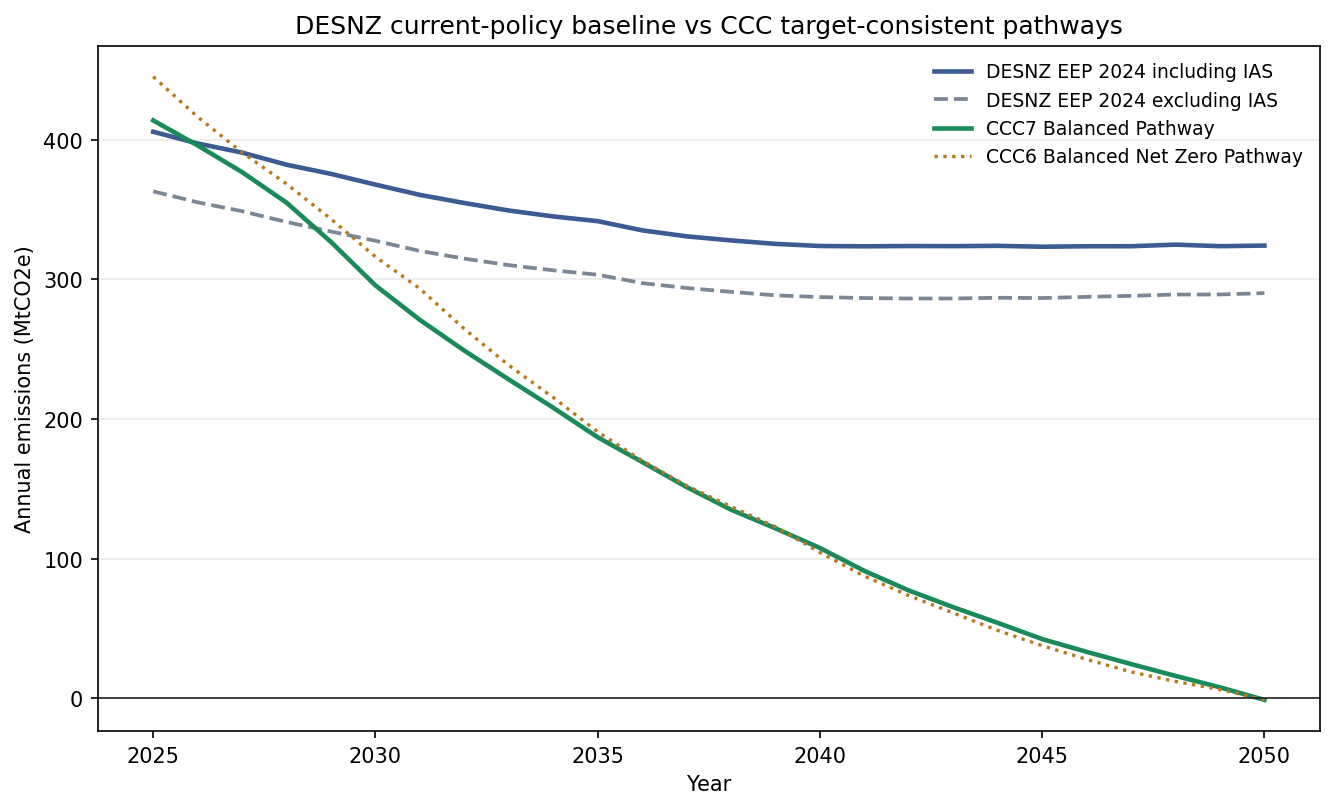

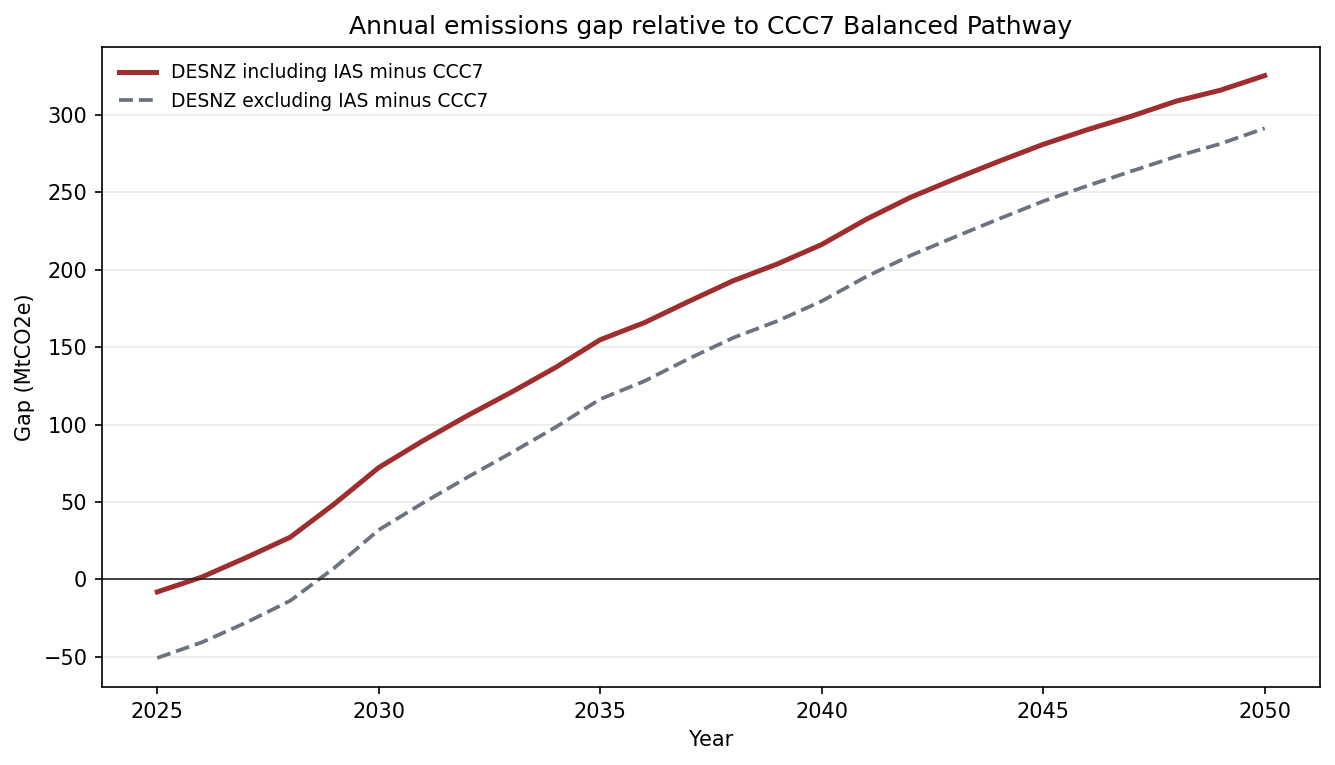

Saved figures:
E:\UCL Final Essay\p4_p5_local_reproduction\figures\p5_cleaned_desnz_vs_ccc_annual_pathways.png
E:\UCL Final Essay\p4_p5_local_reproduction\figures\p5_cleaned_annual_gap_vs_ccc7.png


In [9]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    annual["year"],
    annual["DESNZ_EEP_2024_inc_IAS_MtCO2e"],
    label="DESNZ EEP 2024 including IAS",
    color="#3B5B92",
    linewidth=2.2,
)
ax.plot(
    annual["year"],
    annual["DESNZ_EEP_2024_excl_IAS_MtCO2e"],
    label="DESNZ EEP 2024 excluding IAS",
    color="#7B8794",
    linewidth=1.8,
    linestyle="--",
)
ax.plot(
    annual["year"],
    annual["CCC7_Balanced_Pathway_MtCO2e"],
    label="CCC7 Balanced Pathway",
    color="#1B8A5A",
    linewidth=2.2,
)
ax.plot(
    annual["year"],
    annual["CCC6_Balanced_Net_Zero_Pathway_MtCO2e"],
    label="CCC6 Balanced Net Zero Pathway",
    color="#B7791F",
    linewidth=1.6,
    linestyle=":",
)
ax.axhline(0, color="#222222", linewidth=0.8)
ax.set_title("DESNZ current-policy baseline vs CCC target-consistent pathways")
ax.set_xlabel("Year")
ax.set_ylabel("Annual emissions (MtCO2e)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

pathway_png = FIGURES_DIR / "p5_cleaned_desnz_vs_ccc_annual_pathways.png"
pathway_svg = FIGURES_DIR / "p5_cleaned_desnz_vs_ccc_annual_pathways.svg"
fig.savefig(pathway_png, bbox_inches="tight")
fig.savefig(pathway_svg, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(
    annual["year"],
    annual["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"],
    label="DESNZ including IAS minus CCC7",
    color="#9F2D2D",
    linewidth=2.4,
)
ax.plot(
    annual["year"],
    annual["gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e"],
    label="DESNZ excluding IAS minus CCC7",
    color="#6B7280",
    linewidth=1.8,
    linestyle="--",
)
ax.axhline(0, color="#222222", linewidth=0.8)
ax.set_title("Annual emissions gap relative to CCC7 Balanced Pathway")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (MtCO2e)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

gap_png = FIGURES_DIR / "p5_cleaned_annual_gap_vs_ccc7.png"
gap_svg = FIGURES_DIR / "p5_cleaned_annual_gap_vs_ccc7.svg"
fig.savefig(gap_png, bbox_inches="tight")
fig.savefig(gap_svg, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(pathway_png)
print(gap_png)




## 9. Quality checks



In [10]:
quality_checks = []

def add_check(name: str, ok: bool, details: str) -> None:
    quality_checks.append(
        {
            "check": name,
            "status": "PASS" if ok else "FAIL",
            "details": details,
        }
    )


add_check(
    "Annual comparison covers 2025-2050",
    annual["year"].tolist() == years,
    f"min_year={annual['year'].min()}; max_year={annual['year'].max()}; rows={len(annual)}",
)
add_check(
    "No missing values in main annual comparison columns",
    annual[
        [
            "DESNZ_EEP_2024_inc_IAS_MtCO2e",
            "CCC7_Balanced_Pathway_MtCO2e",
            "gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e",
        ]
    ].notna().all().all(),
    "checked DESNZ inc IAS, CCC7, and main CCC7 gap columns",
)
add_check(
    "2050 CCC7 gap matches expected value approximately",
    abs(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2050) - 325.398436382106) < 1e-6,
    f"actual={value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2050):.12f}",
)
add_check(
    "2030 CCC7 gap matches expected value approximately",
    abs(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2030) - 72.21196185522177) < 1e-6,
    f"actual={value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2030):.12f}",
)
add_check(
    "2035 CCC7 gap matches expected value approximately",
    abs(value_for_year("gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e", 2035) - 154.79531249709044) < 1e-6,
    f"actual={value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2035):.12f}",
)
add_check(
    "CB6 CCC7 sum is available from cleaned CCC7 data",
    pd.notna(cb6["CCC7_balanced_sum_MtCO2e_from_cleaned"]),
    f"CB6_CCC7_sum={cb6['CCC7_balanced_sum_MtCO2e_from_cleaned']}",
)
add_check(
    "Figures were saved",
    pathway_png.exists() and gap_png.exists(),
    f"pathway_png={pathway_png.exists()}; gap_png={gap_png.exists()}",
)

quality_checks_df = pd.DataFrame(quality_checks)
quality_checks_path = TABLES_DIR / "p5_cleaned_benchmark_comparison_quality_checks.csv"
quality_checks_df.to_csv(quality_checks_path, index=False, encoding="utf-8-sig")

display(quality_checks_df)

if (quality_checks_df["status"] == "FAIL").any():
    raise ValueError("One or more P5 benchmark comparison quality checks failed.")




,check,status,details
0,Annual comparison covers 2025-2050,PASS,min_year=2025; max_year=2050; rows=26
1,No missing values in main annual comparison co...,PASS,"checked DESNZ inc IAS, CCC7, and main CCC7 gap..."
2,2050 CCC7 gap matches expected value approxima...,PASS,actual=325.398436382106
3,2030 CCC7 gap matches expected value approxima...,PASS,actual=72.211961855222
4,2035 CCC7 gap matches expected value approxima...,PASS,actual=154.795312497090
5,CB6 CCC7 sum is available from cleaned CCC7 data,PASS,CB6_CCC7_sum=944.2228947002052
6,Figures were saved,PASS,pathway_png=True; gap_png=True


## 10. Short benchmark explanation note



In [11]:
note = f"""P5 cleaned benchmark comparison note

Purpose
This note records the P5 DESNZ-versus-CCC benchmark comparison rebuilt from cleaned CCC data.

Inputs
- DESNZ baseline: {DESNZ_PATH}
- CCC7 cleaned main benchmark: {CCC7_PATH}
- CCC6 cleaned sensitivity benchmark: {CCC6_PATH}
- Carbon budget period base table: {CARBON_BUDGET_PATH}

Main benchmark choice
The main benchmark is the CCC Seventh Carbon Budget Balanced Pathway, using cleaned economy-wide direct emissions for the United Kingdom. CCC7 is preferred because it is the most recent target-consistent CCC pathway in the local dataset and is structured cleanly by economy-wide, sector-level, and metadata sheets.

Comparison basis
The main annual comparison uses DESNZ EEP 2024 including-IAS emissions against CCC7 economy-wide direct emissions. DESNZ excluding-IAS is retained only as an accounting sensitivity. CCC6 Balanced Net Zero Pathway is retained only as a sensitivity check.

Key results
- 2030 gap, DESNZ including IAS minus CCC7: {value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2030):.1f} MtCO2e.
- 2035 gap, DESNZ including IAS minus CCC7: {value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2035):.1f} MtCO2e.
- 2050 gap, DESNZ including IAS minus CCC7: {value_for_year('gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e', 2050):.1f} MtCO2e.
- 2050 sensitivity gap against CCC6: {value_for_year('gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e', 2050):.1f} MtCO2e.
- CCC7 CB6-period sum: {float(cb6['CCC7_balanced_sum_MtCO2e_from_cleaned']):.1f} MtCO2e.
- CCC7 CB6-period position relative to CB6 target: {float(cb6['CCC7_minus_target_MtCO2e_from_cleaned']):.1f} MtCO2e.

Outputs
- Annual comparison table: {annual_path}
- Benchmark-year gap table: {benchmark_year_path}
- Carbon-budget-period table: {carbon_budget_path}
- Final benchmark metrics table: {final_metrics_path}
- Pathway figure: {pathway_png}
- Gap figure: {gap_png}
- Quality checks: {quality_checks_path}

Recommended dissertation use
Use the CCC7 comparison as the main P5 result. Use CCC6 and excluding-IAS comparisons only as supporting robustness/accounting checks. The main text should emphasize that the DESNZ baseline diverges from the CCC target-consistent pathway from 2030 onward, with a substantially wider gap by 2035 and a large residual gap by 2050.
"""

note_path = TABLES_DIR / "p5_cleaned_benchmark_comparison_note.txt"
note_path.write_text(note, encoding="utf-8")

print(note)




P5 cleaned benchmark comparison note

Purpose
This note records the P5 DESNZ-versus-CCC benchmark comparison rebuilt from cleaned CCC data.

Inputs
- DESNZ baseline: E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\desnz_annual_territorial_pathway.csv
- CCC7 cleaned main benchmark: E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\ccc7_clean_economy_wide_balanced_pathway.csv
- CCC6 cleaned sensitivity benchmark: E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\ccc6_clean_balanced_net_zero_pathway.csv
- Carbon budget period base table: E:\UCL Final Essay\p4_p5_local_reproduction\tables\carbon_budget_gap_metrics.csv

Main benchmark choice
The main benchmark is the CCC Seventh Carbon Budget Balanced Pathway, using cleaned economy-wide direct emissions for the United Kingdom. CCC7 is preferred because it is the most recent target-consistent CCC pathway in the local dataset and is structured cleanly by economy-wide, sector-level, and metadata sheets.

Comparison

## 11. Output manifest



In [12]:
manifest = pd.DataFrame(
    [
        {"output": str(annual_path), "role": "P5 annual DESNZ vs CCC comparison from cleaned CCC data"},
        {"output": str(benchmark_year_path), "role": "P5 benchmark-year gap table"},
        {"output": str(carbon_budget_path), "role": "P5 carbon-budget-period comparison using cleaned CCC data"},
        {"output": str(final_metrics_path), "role": "P5 final benchmark metrics table"},
        {"output": str(pathway_png), "role": "Pathway comparison figure"},
        {"output": str(pathway_svg), "role": "Pathway comparison figure, SVG"},
        {"output": str(gap_png), "role": "Annual gap figure"},
        {"output": str(gap_svg), "role": "Annual gap figure, SVG"},
        {"output": str(quality_checks_path), "role": "Quality checks"},
        {"output": str(note_path), "role": "Benchmark comparison note"},
    ]
)
manifest_path = TABLES_DIR / "p5_cleaned_benchmark_comparison_output_manifest.csv"
manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(manifest)

print("P5 benchmark comparison from cleaned CCC data complete.")


,output,role
0,E:\UCL Final Essay\p4_p5_local_reproduction\da...,P5 annual DESNZ vs CCC comparison from cleaned...
1,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,P5 benchmark-year gap table
2,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,P5 carbon-budget-period comparison using clean...
3,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,P5 final benchmark metrics table
4,E:\UCL Final Essay\p4_p5_local_reproduction\fi...,Pathway comparison figure
5,E:\UCL Final Essay\p4_p5_local_reproduction\fi...,"Pathway comparison figure, SVG"
6,E:\UCL Final Essay\p4_p5_local_reproduction\fi...,Annual gap figure
7,E:\UCL Final Essay\p4_p5_local_reproduction\fi...,"Annual gap figure, SVG"
8,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,Quality checks
9,E:\UCL Final Essay\p4_p5_local_reproduction\ta...,Benchmark comparison note


P5 benchmark comparison from cleaned CCC data complete.
